In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("F:/1. projects/credit card/dataset/CC GENERAL.csv")

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
print(df.dtypes)

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [7]:
print(df.isnull().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Minimum Payments and Credit Limit have missing values, so fill them with medians

In [8]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [9]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [10]:
print(df.isnull().sum())

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [11]:
#Checking for duplicates
print(f"Duplicates:{df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Duplicates:0


EDA

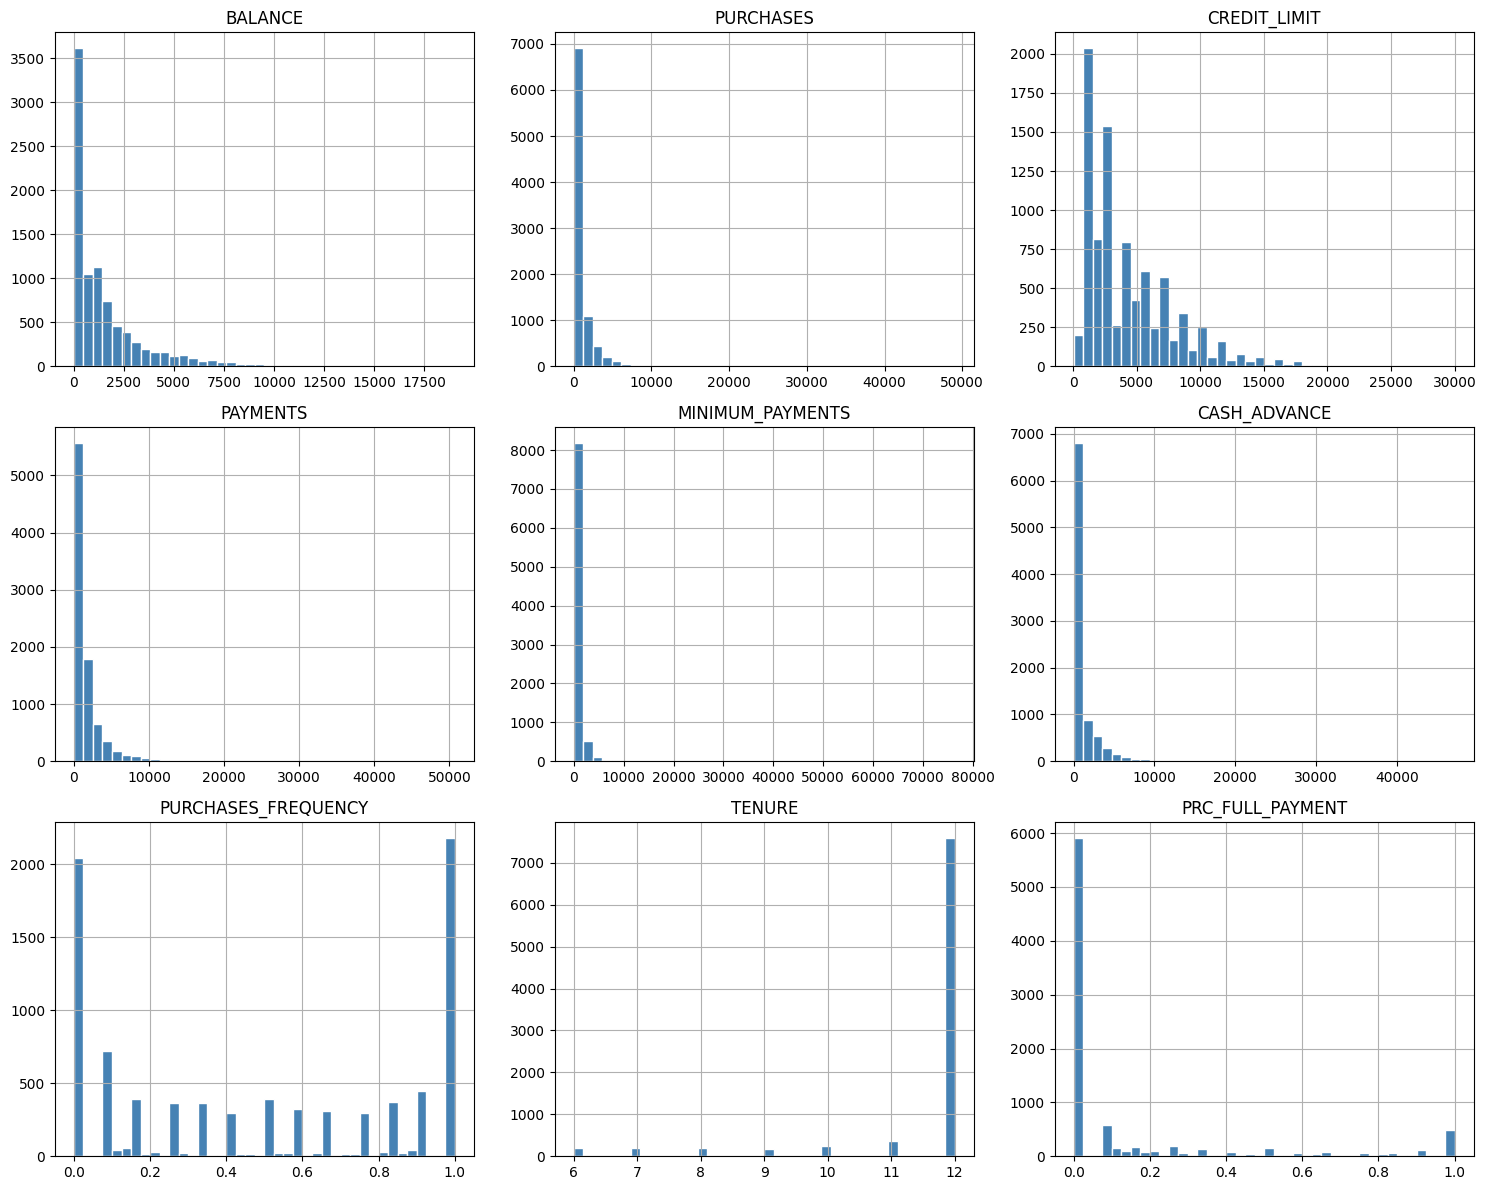

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT',
        'PAYMENTS', 'MINIMUM_PAYMENTS', 'CASH_ADVANCE',
        'PURCHASES_FREQUENCY', 'TENURE', 'PRC_FULL_PAYMENT']

for ax, col in zip(axes.flatten(), cols):
    df[col].hist(ax=ax, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/distributions.png')
plt.show()

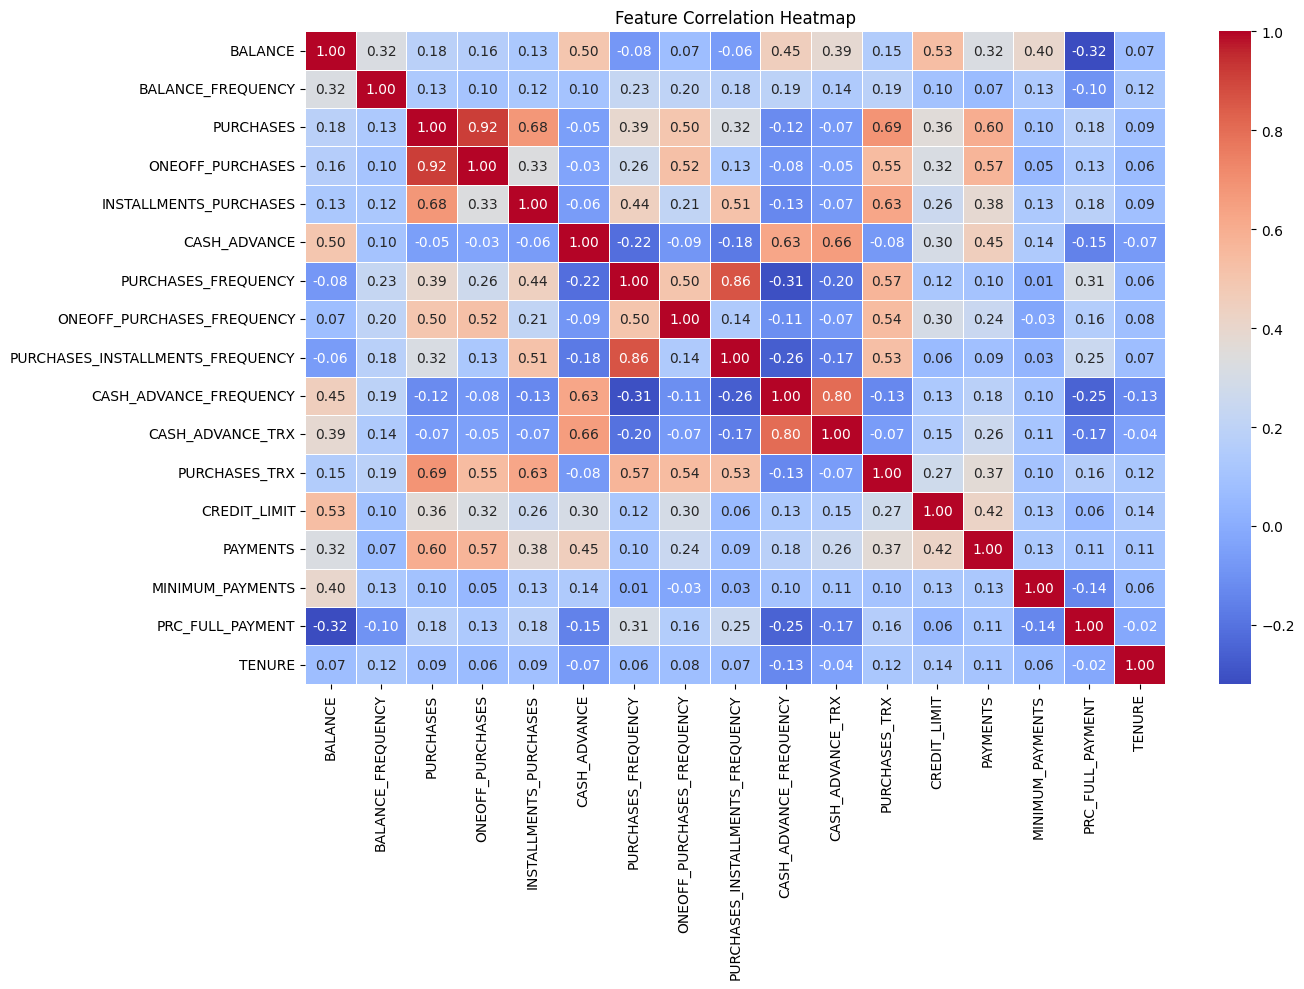

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/correlation.png')
plt.show()

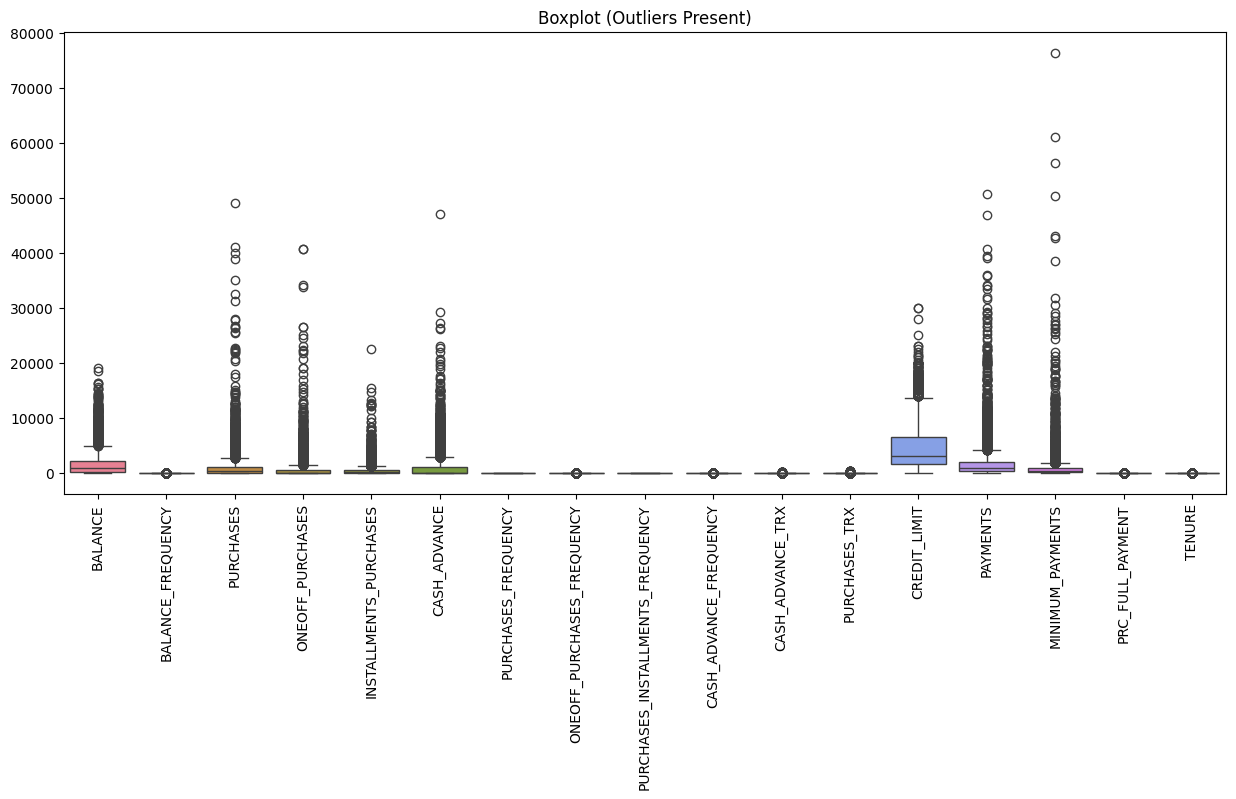

In [14]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot (Outliers Present)")
plt.show()

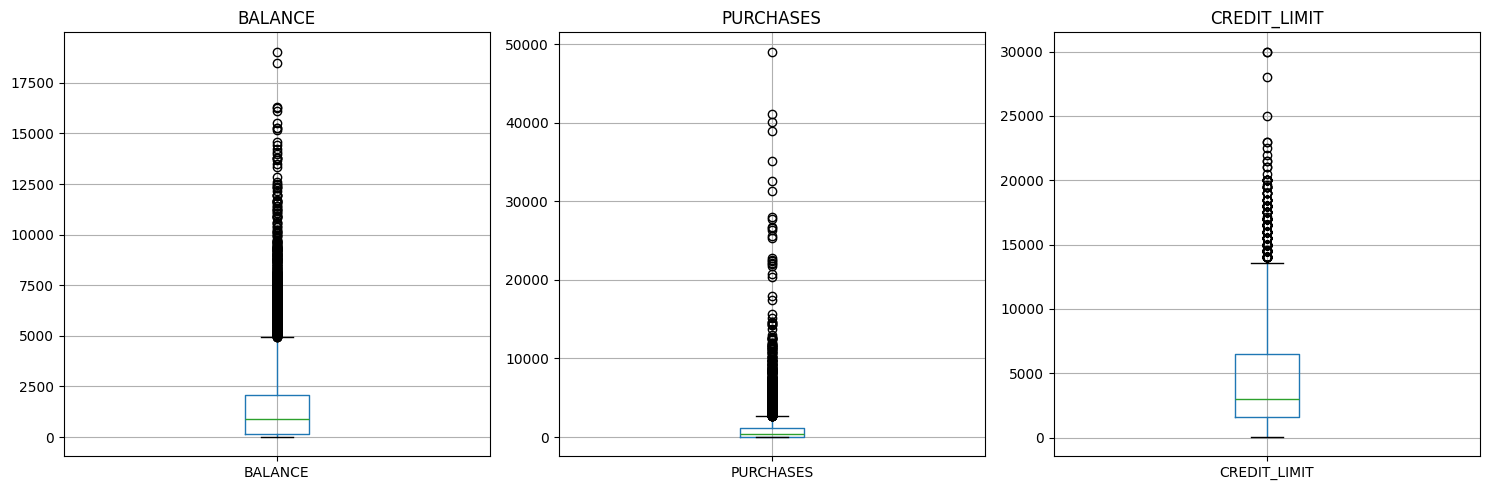

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [18]:
# Pre-Clustering Visualizations (Simplified)
# Main pre-clustering chart: utilization histogram.
# Additional visual (spending vs payment) is kept as appendix.

In [19]:
# Clustered export happens after the cluster labels are created.
# This placeholder keeps the notebook flow readable.
print('Clustered export will be written after K-Means is fit.')

Clustered export will be written after K-Means is fit.


✓ Clustered customers saved to: F:/1. projects/credit card/dataset/clustered_customers.csv
  Total records: 8950
  Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'Cluster']
KMeans clustering completed with K=4
Cluster distribution:
0    7141
1    1442
2     329
3      38
Name: count, dtype: int64


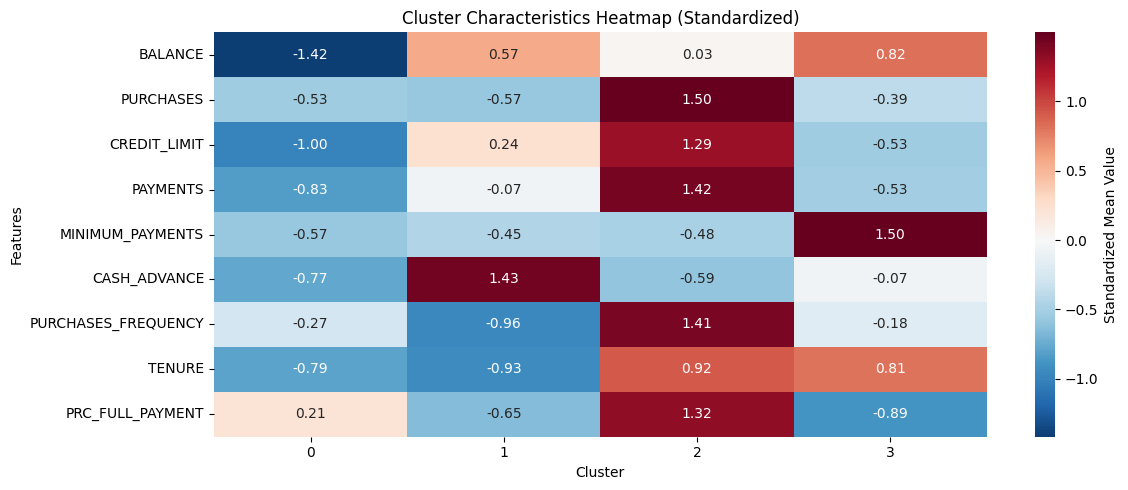

In [20]:
# Prepare the modeling data and create cluster labels before profiling.
df_cluster = df.drop(columns=['CUST_ID', 'UTILIZATION_RATIO', 'PAYMENT_RATIO', 'CASH_ADV_RATIO', 'Cluster'], errors='ignore')
df_scaled = RobustScaler().fit_transform(df_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)
df['Cluster'] = clusters

output_path = 'F:/1. projects/credit card/dataset/clustered_customers.csv'
df.to_csv(output_path, index=False)
print(f"✓ Clustered customers saved to: {output_path}")
print(f"  Total records: {len(df)}")
print(f"  Columns: {df.columns.tolist()}")
print(f"KMeans clustering completed with K={kmeans.n_clusters}")
print(f"Cluster distribution:\n{pd.Series(clusters).value_counts().sort_index()}")

# Cluster Characteristics Heatmap (standardized mean values)
cluster_chars = df.groupby('Cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 
                                        'MINIMUM_PAYMENTS', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 
                                        'TENURE', 'PRC_FULL_PAYMENT']].mean()

# Standardize for heatmap (z-score)
cluster_chars_std = (cluster_chars - cluster_chars.mean()) / cluster_chars.std()

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_chars_std.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Standardized Mean Value'})
plt.title('Cluster Characteristics Heatmap (Standardized)')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/cluster_characteristics.png')
plt.show()

In [21]:
# Create simplified cluster summary table
cluster_summary = df.groupby('Cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 
                                         'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'PRC_FULL_PAYMENT']].mean().round(2)
cluster_summary['Size'] = df['Cluster'].value_counts().sort_index()
cluster_summary['% of Total'] = (cluster_summary['Size'] / len(df) * 100).round(1)

print("\n" + "="*80)
print("CLUSTER SUMMARY TABLE")
print("="*80)
print(cluster_summary)


CLUSTER SUMMARY TABLE
         BALANCE  PURCHASES  CREDIT_LIMIT  PAYMENTS  CASH_ADVANCE  \
Cluster                                                             
0         918.36     734.08       3757.99   1092.82        363.73   
1        4269.30     579.21       6953.40   3448.14       4080.76   
2        3371.94    8669.28       9643.16   8080.23        669.97   
3        4692.50    1294.76       4964.47   2031.75       1542.36   

         PURCHASES_FREQUENCY  PRC_FULL_PAYMENT  Size  % of Total  
Cluster                                                           
0                       0.50              0.17  7141        79.8  
1                       0.33              0.04  1442        16.1  
2                       0.93              0.34   329         3.7  
3                       0.53              0.00    38         0.4  


In [22]:
# Generate Cluster Profiles - Summary Statistics
df['Cluster'] = clusters

cluster_profiles = df.groupby('Cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 
                                           'MINIMUM_PAYMENTS', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 
                                           'TENURE', 'PRC_FULL_PAYMENT']].agg(['mean', 'median', 'std']).round(2)

print("="*80)
print("CLUSTER PROFILES - Summary Statistics")
print("="*80)
print(cluster_profiles)

# Also get cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()
print("\n" + "="*80)
print("CLUSTER SIZES")
print("="*80)
print(cluster_sizes)
print(f"\nTotal customers: {cluster_sizes.sum()}")

CLUSTER PROFILES - Summary Statistics
         BALANCE                   PURCHASES                   CREDIT_LIMIT  \
            mean   median      std      mean   median      std         mean   
Cluster                                                                       
0         918.36   477.82  1126.78    734.08   367.95   947.86      3757.99   
1        4269.30  3799.07  2702.16    579.21   120.64   947.04      6953.40   
2        3371.94  2163.68  3438.60   8669.28  6558.55  6256.06      9643.16   
3        4692.50  3629.00  2992.24   1294.76   470.82  2294.99      4964.47   

                         PAYMENTS  ... CASH_ADVANCE PURCHASES_FREQUENCY  \
         median      std     mean  ...          std                mean   
Cluster                            ...                                    
0        2900.0  3079.63  1092.82  ...       698.26                0.50   
1        6500.0  3838.16  3448.14  ...      3460.79                0.33   
2        9000.0  4862.07  8080.23

C:\Users\vijet\AppData\Local\Temp\ipykernel_2552\264098171.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(cluster_names))


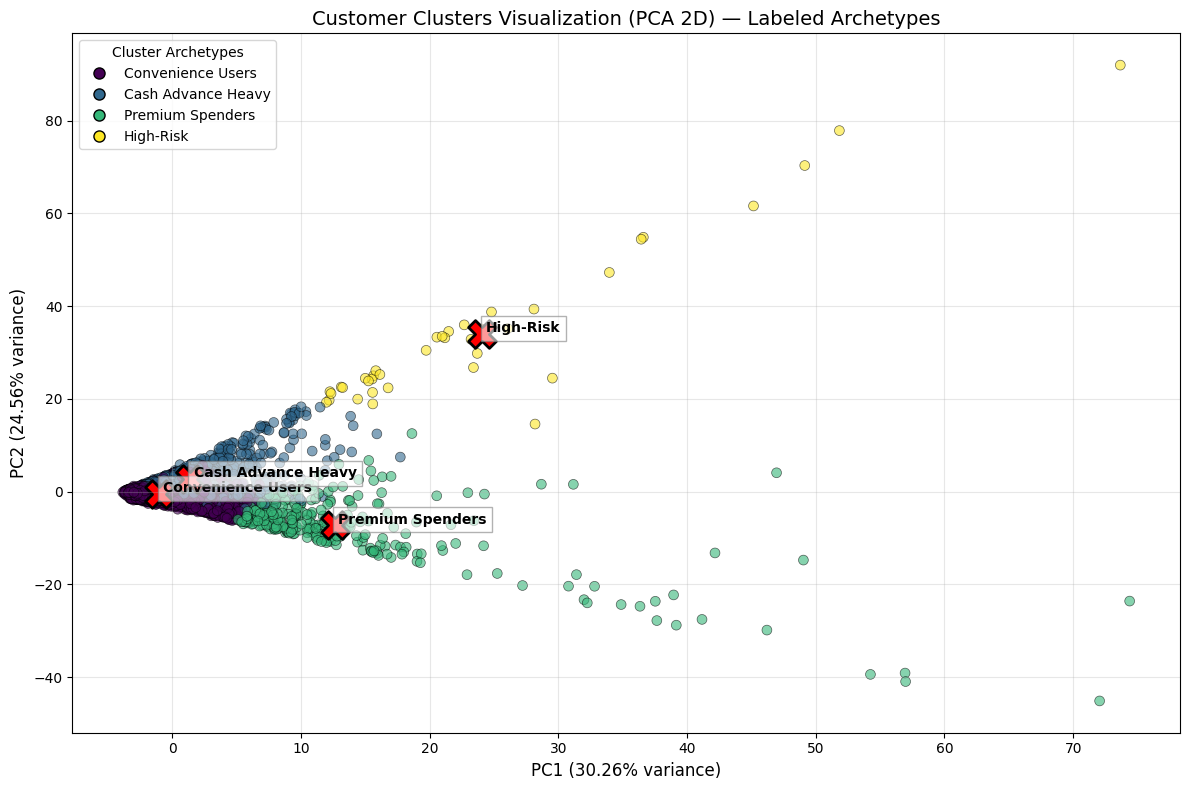

Total variance explained by PC1 and PC2: 54.83%


In [23]:
# PCA 2D Visualization for Cluster Validation
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Define cluster names (archetypes)
cluster_names = {
    0: 'Convenience Users',
    1: 'Cash Advance Heavy',
    2: 'Premium Spenders',
    3: 'High-Risk'
}

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters, cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=400, 
           edgecolors='black', linewidth=2, label='Cluster Centers')

# Annotate cluster centers with names
for idx, name in cluster_names.items():
    if idx < len(centers_pca):
        plt.text(centers_pca[idx, 0] + 0.3, centers_pca[idx, 1] + 0.3, name,
                 fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

# Create a legend mapping colors to cluster names
cmap = plt.cm.get_cmap('viridis', len(cluster_names))
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=8, 
                      markeredgecolor='black') for i in range(len(cluster_names))]
labels = [cluster_names[i] for i in range(len(cluster_names))]
plt.legend(handles, labels, title='Cluster Archetypes', loc='best')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Customer Clusters Visualization (PCA 2D) — Labeled Archetypes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/pca_clusters_labeled.png')
plt.show()

print(f"Total variance explained by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2%}")

In [24]:
# Fit KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Attach the cluster labels immediately so later profile cells can use them.
df['Cluster'] = clusters

print(f"KMeans clustering completed")
print(f"Cluster distribution:\n{pd.Series(clusters).value_counts().sort_index()}")

KMeans clustering completed
Cluster distribution:
0    7141
1    1442
2     329
3      38
Name: count, dtype: int64


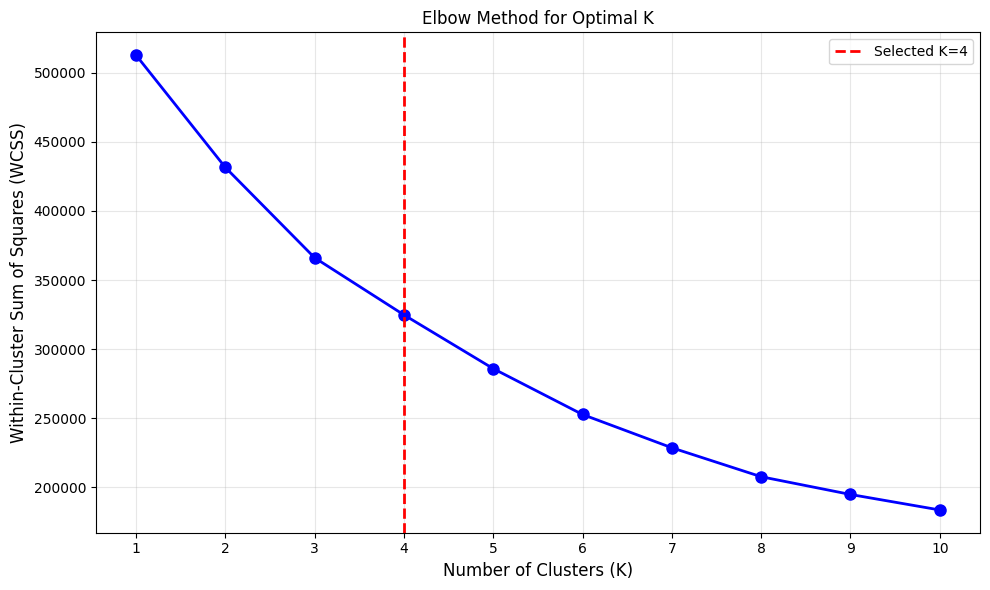

WCSS values: [512746.38525838417, 431512.4849513858, 366126.1763927508, 324793.6210351496, 285897.5124911334, 252720.59900235082, 228637.2122769576, 207696.98978303774, 194859.56131031035, 183639.81420644582]

Note: No sharp elbow found — typical for real-world financial data.
K=4 selected for business interpretability (4 actionable customer archetypes)


In [25]:
# Elbow Method: Find optimal K
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.axvline(x=4, color='red', linestyle='--', label='Selected K=4', linewidth=2)
plt.legend()
plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/elbow_method.png')
plt.show()

print("WCSS values:", wcss)
print("\nNote: No sharp elbow found — typical for real-world financial data.")
print("K=4 selected for business interpretability (4 actionable customer archetypes)")

In [26]:
# Apply RobustScaler to handle outliers
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_cluster)
print("Data scaled successfully")
print("Scaled data shape:", df_scaled.shape)

Data scaled successfully
Scaled data shape: (8950, 17)


In [27]:
# Drop identifier and any optional derived/helper columns before clustering
cols_to_drop = ['CUST_ID', 'UTILIZATION_RATIO', 'PAYMENT_RATIO', 'CASH_ADV_RATIO', 'Cluster']
df_cluster = df.drop(columns=cols_to_drop, errors='ignore')
print("Features for clustering:", df_cluster.columns.tolist())
print("Shape before scaling:", df_cluster.shape)

Features for clustering: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Shape before scaling: (8950, 17)


## Data Preparation & Clustering

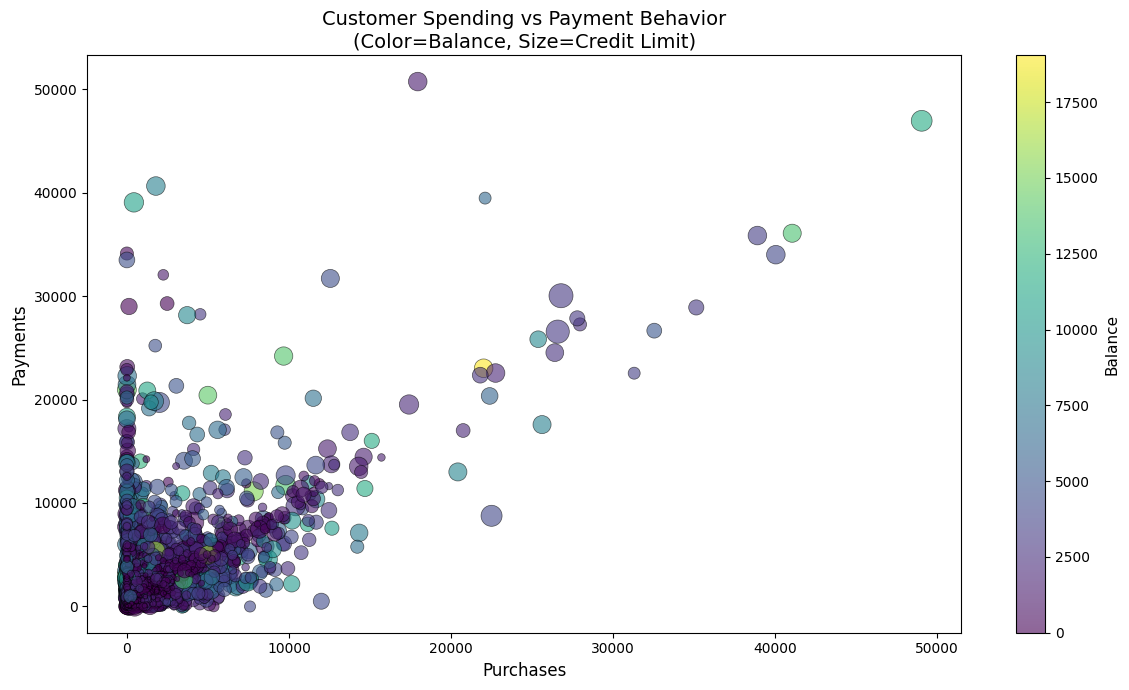

In [28]:
# Spending vs Payment Behavior Scatter Plot
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['PURCHASES'], df['PAYMENTS'], c=df['BALANCE'], 
                     s=df['CREDIT_LIMIT']/100, alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)
plt.xlabel('Purchases', fontsize=12)
plt.ylabel('Payments', fontsize=12)
plt.title('Customer Spending vs Payment Behavior\n(Color=Balance, Size=Credit Limit)', fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Balance', fontsize=11)
plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/spending_vs_payment.png')
plt.show()

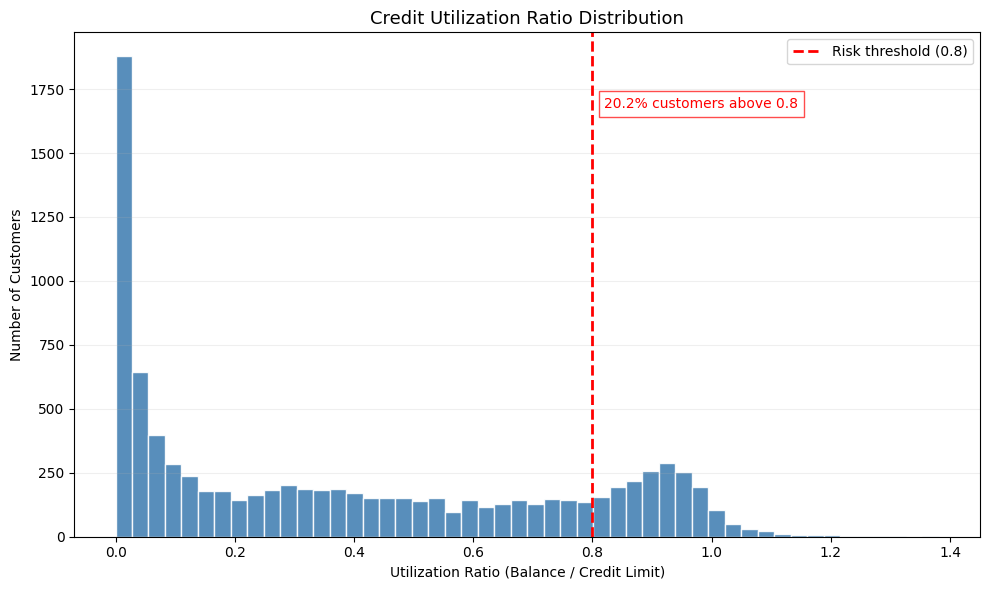

Percent of customers with utilization > 0.8: 20.25%
Saved: F:/1. projects/credit card/eda/utilization.png


In [30]:
# Simple pre-clustering view: credit utilization distribution
# Utilization > 0.8 is often treated as a high-risk credit behavior threshold.
df['UTILIZATION_RATIO'] = df['BALANCE'] / (df['CREDIT_LIMIT'] + 1e-10)

# Clip visualization range for readability while retaining high-risk tail insight.
util_viz = df.loc[df['UTILIZATION_RATIO'] <= 1.5, 'UTILIZATION_RATIO']
percent_above = (df['UTILIZATION_RATIO'] > 0.8).mean() * 100

plt.figure(figsize=(10, 6))
plt.hist(util_viz, bins=50, color='steelblue', edgecolor='white', alpha=0.9)
plt.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Risk threshold (0.8)')
plt.title('Credit Utilization Ratio Distribution', fontsize=13)
plt.xlabel('Utilization Ratio (Balance / Credit Limit)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.text(
    0.82,
    plt.ylim()[1] * 0.85,
    f"{percent_above:.1f}% customers above 0.8",
    color='red',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='red')
)

plt.tight_layout()
plt.savefig('F:/1. projects/credit card/eda/utilization.png', dpi=300)
plt.show()

print(f"Percent of customers with utilization > 0.8: {percent_above:.2f}%")
print("Saved: F:/1. projects/credit card/eda/utilization.png")


This chart shows how much of their credit limit customers are using.
Most customers are concentrated at lower utilization levels, but the right tail highlights a smaller higher-risk group.
The red line at 0.8 marks a common practical threshold: customers above this level are often considered financially stretched.
This supports why some customers later appear in risk-oriented clusters such as Cash Advance Heavy.

- This plot gives a quick risk snapshot before clustering.
- A utilization ratio above 0.8 suggests possible repayment pressure.
- The majority are low-to-moderate users, supporting a large stable segment.
- The high-utilization tail supports the existence of smaller, higher-risk archetypes.